In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d1=pd.read_csv('/content/flights.csv')
d2=pd.read_csv('/content/flights_cleaned.csv')

In [ ]:
display(d1.head())

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


In [ ]:
display(d2.head())

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,date,Day_of_Week,Is_weekend,departure_period,Departure_Delay_Flag,Arrival_Delay_Flag,Delay_Severity,Route,Distance_Category,delay_cause
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,01-01-2013,1,0,Morning,1,1,Slight Delay,EWR-IAH,Long Distance,Minor Operational Delay
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,01-01-2013,1,0,Morning,1,1,Slight Delay,LGA-IAH,Long Distance,Ground Operations Delay
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,01-01-2013,1,0,Morning,1,1,Medium Delay,JFK-MIA,Long Distance,Ground Operations Delay
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,01-01-2013,1,0,Morning,0,0,On Time,JFK-BQN,Long Distance,On-time
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,01-01-2013,1,0,Morning,0,0,On Time,LGA-ATL,Medium Distance,On-time


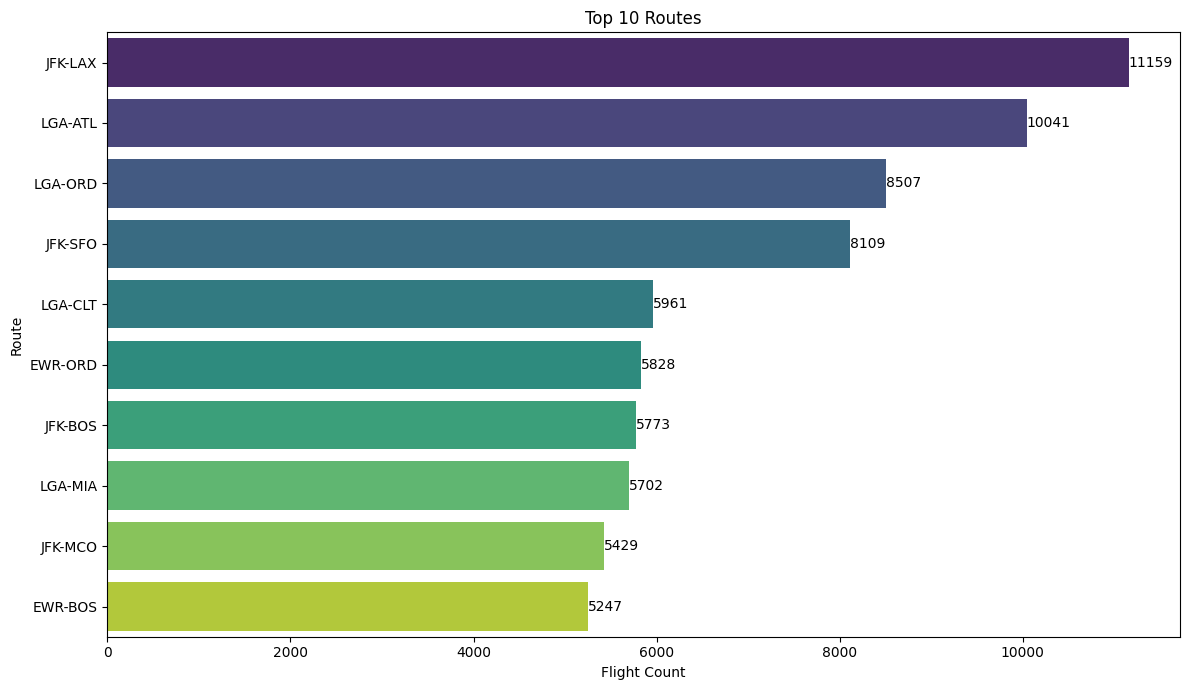

In [ ]:

#EWR: Newark Liberty International Airport
#JFK: John F. Kennedy International Airport
#LGA: LaGuardia Airport
#ATL: Hartsfield-Jackson Atlanta International Airport
#BOS: Logan International Airport
#CLT: Charlotte Douglas International Airport
#LAX: Los Angeles International Airport
#MCO: Orlando International Airport
#MIA: Miami International Airport
#ORD: O'Hare International Airport
#SFO: San Francisco International Airport
top_10_routes = d2.groupby('Route').size().nlargest(10).reset_index(name='flight_count')
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='flight_count', y='Route', data=top_10_routes, palette='viridis', hue='Route', legend=False)
plt.title('Top 10 Routes')
plt.xlabel('Flight Count')
plt.ylabel('Route')

for index, row in top_10_routes.iterrows():
    ax.text(row.flight_count, index, f'{row.flight_count}', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

In [ ]:
avg_delay_by_route = d2.groupby('Route')[['dep_delay', 'arr_delay']].mean().reset_index()
display(avg_delay_by_route.head())

,Route,dep_delay,arr_delay
0,EWR-ALB,23.447368,14.397129
1,EWR-ANC,12.875000,-2.500000
2,EWR-ATL,15.393560,13.233183
3,EWR-AUS,11.474399,-0.474399
4,EWR-AVL,8.577689,8.804781


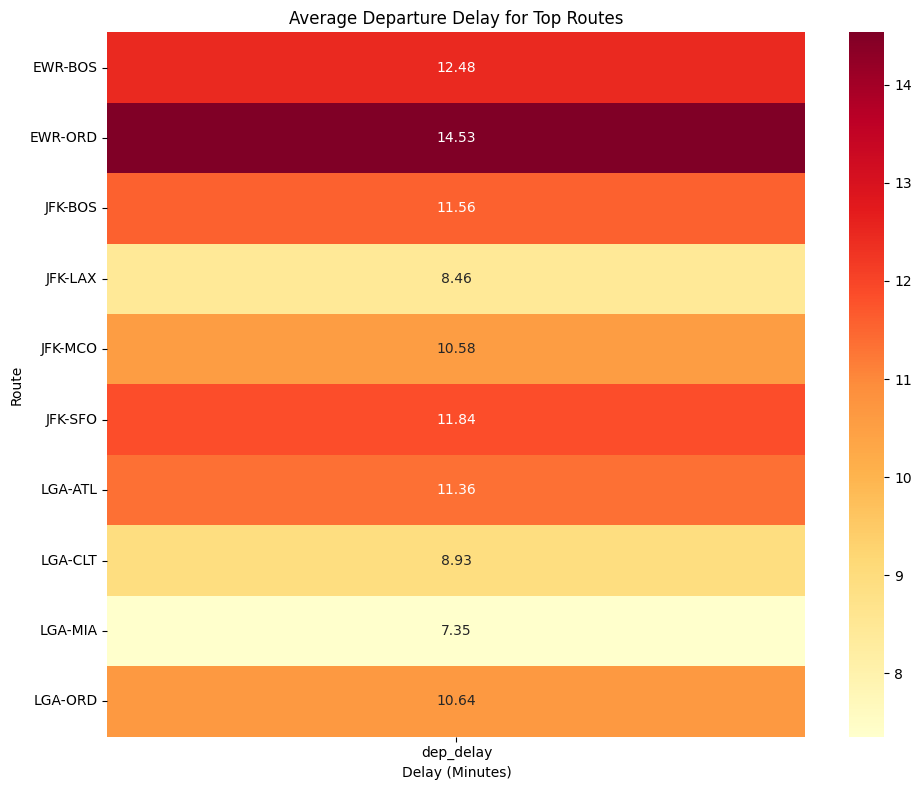

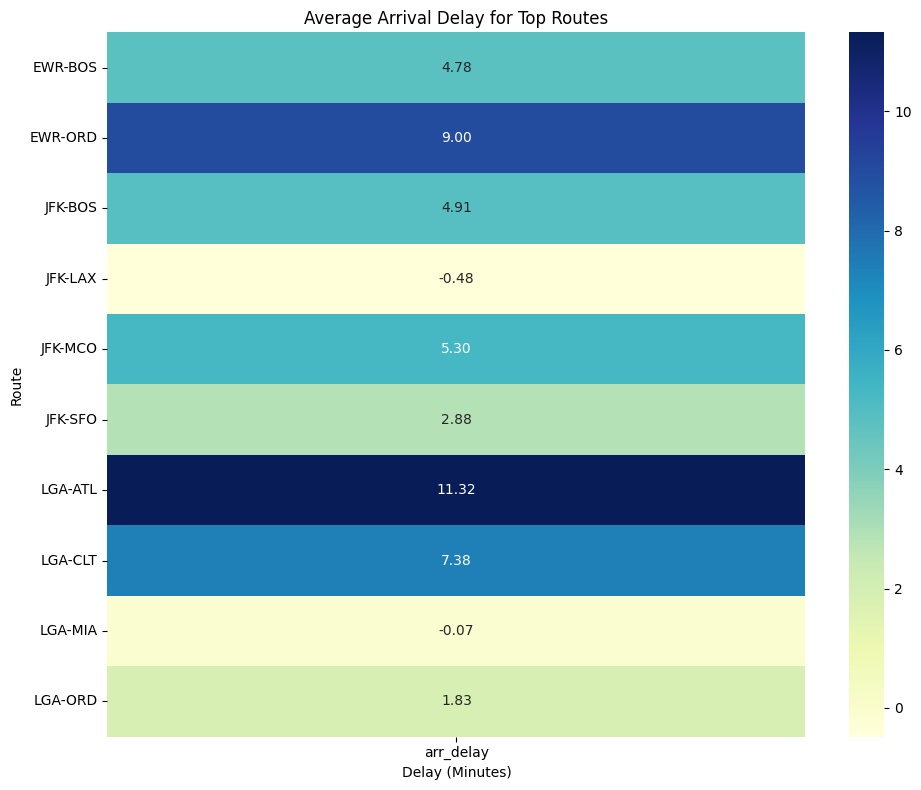

In [ ]:


top_routes_list = top_10_routes['Route'].tolist()

top_route_delays = avg_delay_by_route[avg_delay_by_route['Route'].isin(top_routes_list)].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(
    data=top_route_delays[['Route', 'dep_delay']].set_index('Route'),
    annot=True,
    cmap='YlOrRd',
    fmt=".2f"
)
plt.title('Average Departure Delay for Top Routes')
plt.xlabel('Delay (Minutes)')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    data=top_route_delays[['Route', 'arr_delay']].set_index('Route'),
    annot=True,
    cmap='YlGnBu',
    fmt=".2f"
)
plt.title('Average Arrival Delay for Top Routes')
plt.xlabel('Delay (Minutes)')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

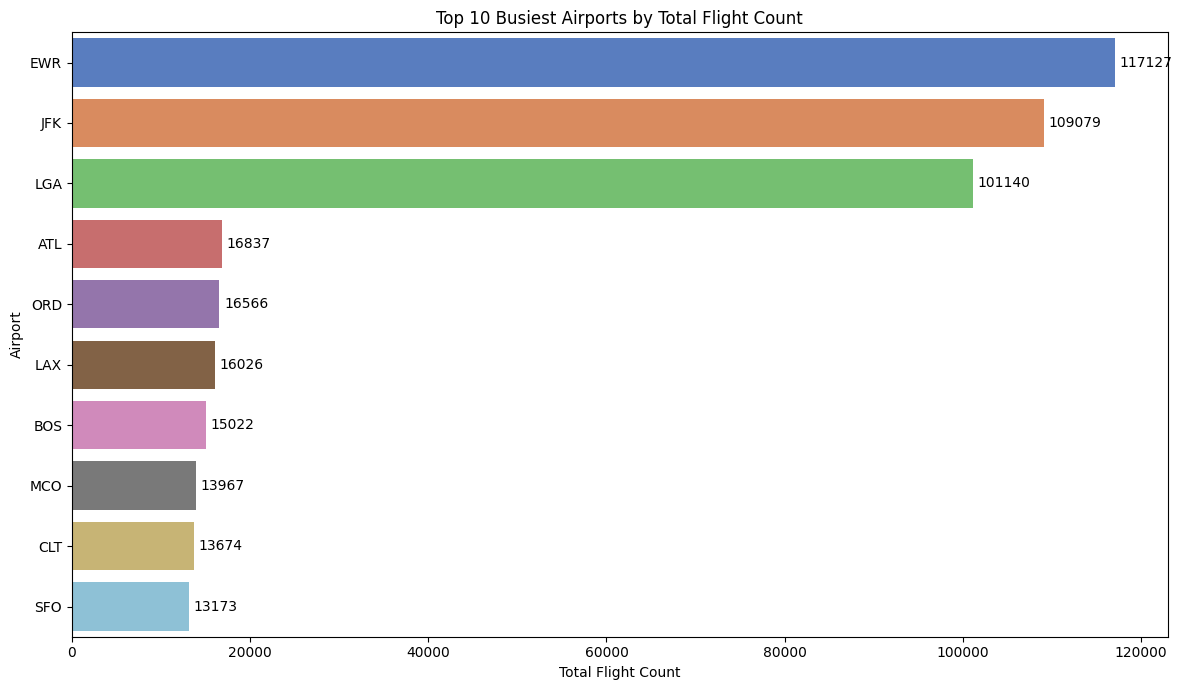

In [ ]:
origin_counts = d2['origin'].value_counts()
dest_counts = d2['dest'].value_counts()
total_flight_counts = origin_counts.add(dest_counts, fill_value=0).sort_values(ascending=False)
top_10_busiest_airports = total_flight_counts.nlargest(10).reset_index()
top_10_busiest_airports.columns = ['airport', 'total_flights']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='total_flights', y='airport', data=top_10_busiest_airports, palette='muted', hue='airport', legend=False)
plt.title('Top 10 Busiest Airports by Total Flight Count')
plt.xlabel('Total Flight Count')
plt.ylabel('Airport')

for index, row in top_10_busiest_airports.iterrows():
    ax.text(row.total_flights + 500, index, f'{row.total_flights:.0f}', color='black', ha='left', va='center')

plt.tight_layout()
plt.show()

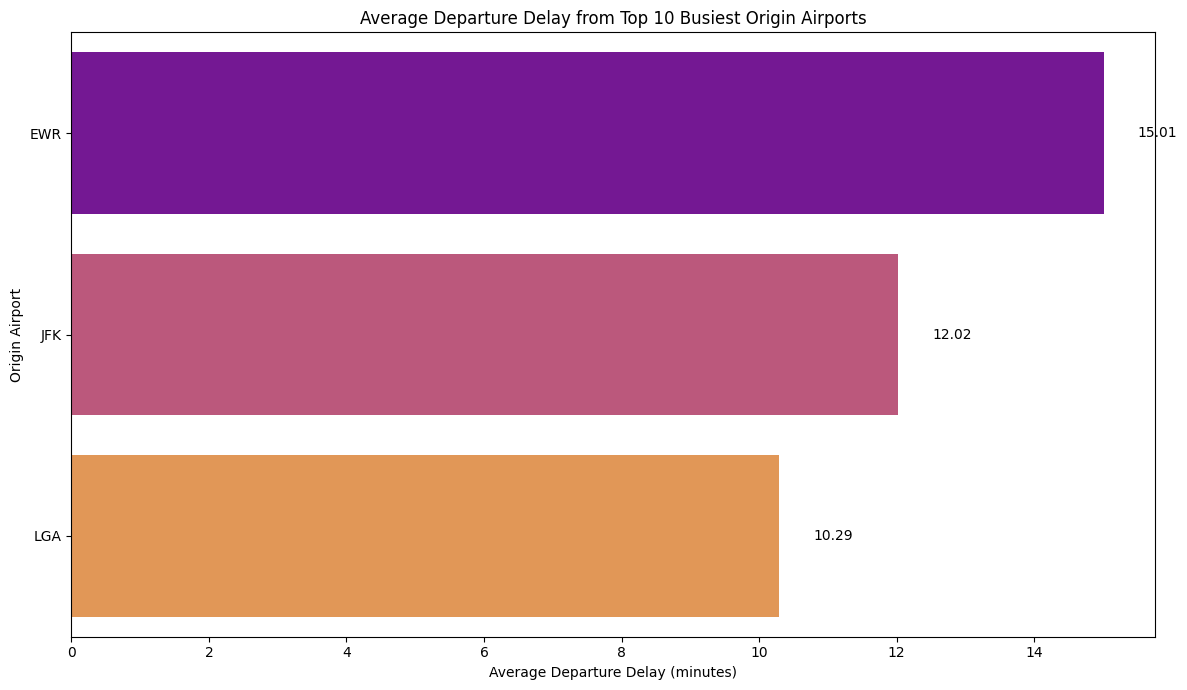

In [ ]:
avg_dep_delay_origin_all = d2.groupby('origin')['dep_delay'].mean().reset_index()
top_10_busiest_airport_codes = top_10_busiest_airports['airport'].tolist()
top_dep_delay_origin = avg_dep_delay_origin_all[avg_dep_delay_origin_all['origin'].isin(top_10_busiest_airport_codes)].copy()


plt.figure(figsize=(12, 7))
ax = sns.barplot(x='dep_delay', y='origin', data=top_dep_delay_origin.sort_values(by='dep_delay', ascending=False), palette='plasma', hue='origin', legend=False)
plt.title('Average Departure Delay from Top 10 Busiest Origin Airports')
plt.xlabel('Average Departure Delay (minutes)')
plt.ylabel('Origin Airport')
for index, row in top_dep_delay_origin.sort_values(by='dep_delay', ascending=False).iterrows():
    ax.text(row.dep_delay + 0.5, index, f'{row.dep_delay:.2f}', color='black', ha='left', va='center')
plt.tight_layout()
plt.show()

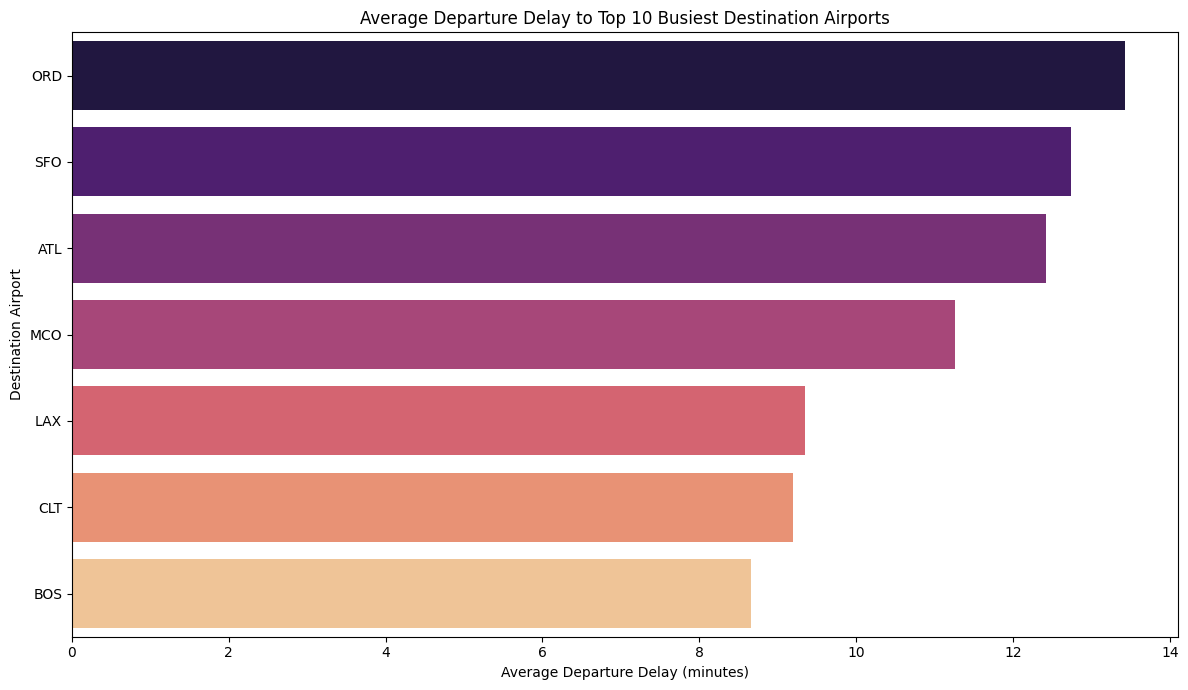

In [ ]:

avg_dep_delay_dest_all = d2.groupby('dest')['dep_delay'].mean().reset_index()
top_10_busiest_airport_codes = top_10_busiest_airports['airport'].tolist()
top_dep_delay_dest = avg_dep_delay_dest_all[avg_dep_delay_dest_all['dest'].isin(top_10_busiest_airport_codes)].copy()

plt.figure(figsize=(12, 7))
sns.barplot(x='dep_delay', y='dest', data=top_dep_delay_dest.sort_values(by='dep_delay', ascending=False), palette='magma', hue='dest', legend=False)
plt.title('Average Departure Delay to Top 10 Busiest Destination Airports')
plt.xlabel('Average Departure Delay (minutes)')
plt.ylabel('Destination Airport')
plt.tight_layout()
plt.show()

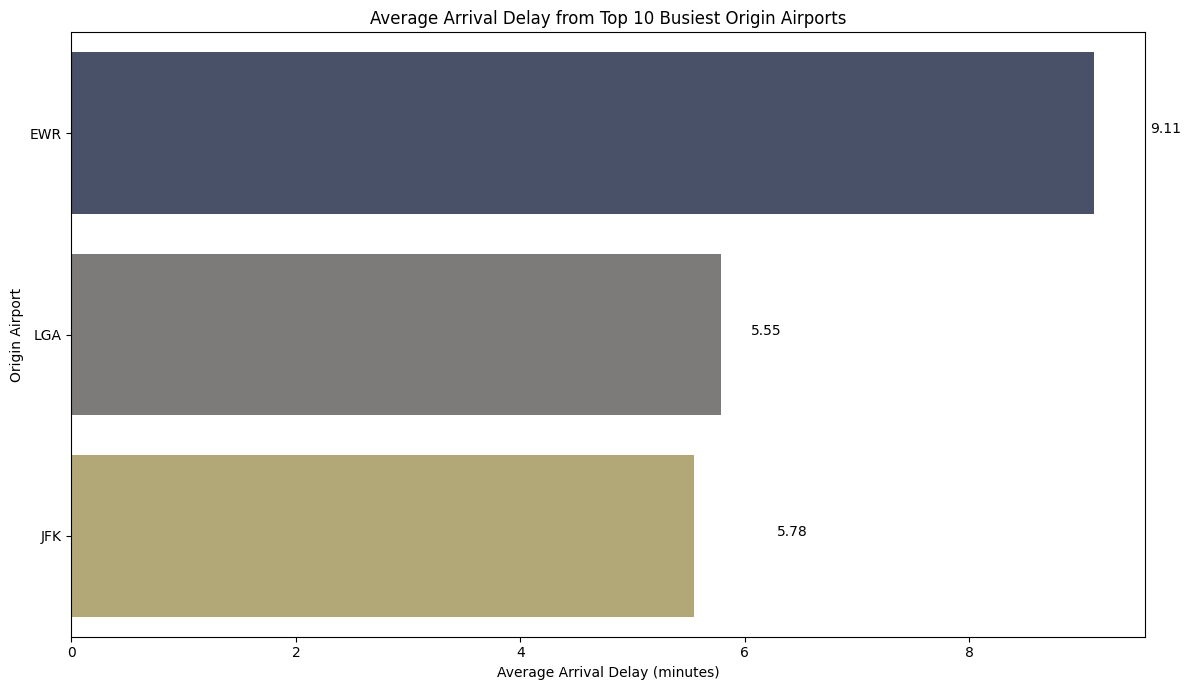

In [ ]:
avg_arr_delay_origin_all = d2.groupby('origin')['arr_delay'].mean().reset_index()
top_10_busiest_airport_codes = top_10_busiest_airports['airport'].tolist()
top_arr_delay_origin = avg_arr_delay_origin_all[avg_arr_delay_origin_all['origin'].isin(top_10_busiest_airport_codes)].copy()


plt.figure(figsize=(12, 7))
ax = sns.barplot(x='arr_delay', y='origin', data=top_arr_delay_origin.sort_values(by='arr_delay', ascending=False), palette='cividis', hue='origin', legend=False)
plt.title('Average Arrival Delay from Top 10 Busiest Origin Airports')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Origin Airport')
for index, row in top_arr_delay_origin.sort_values(by='arr_delay', ascending=False).iterrows():
    ax.text(row.arr_delay + 0.5, index, f'{row.arr_delay:.2f}', color='black', ha='left')
plt.tight_layout()
plt.show()

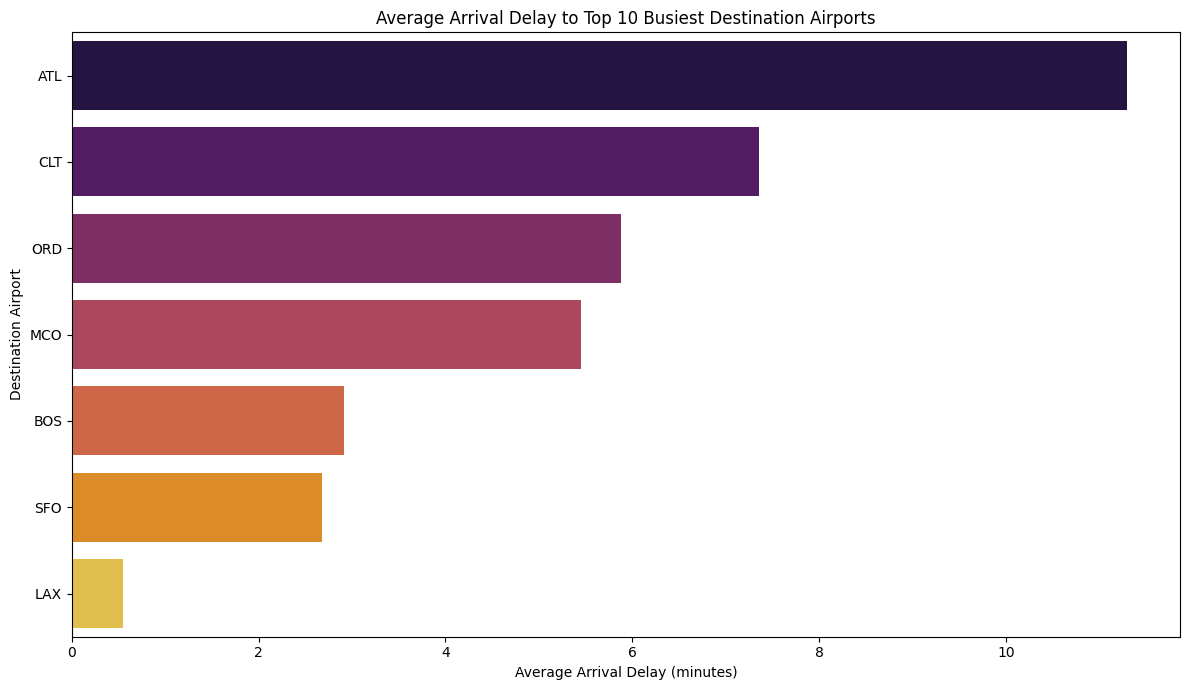

In [ ]:
avg_arr_delay_dest_all = d2.groupby('dest')['arr_delay'].mean().reset_index()
top_10_busiest_airport_codes = top_10_busiest_airports['airport'].tolist()
top_arr_delay_dest = avg_arr_delay_dest_all[avg_arr_delay_dest_all['dest'].isin(top_10_busiest_airport_codes)].copy()

plt.figure(figsize=(12, 7))
sns.barplot(x='arr_delay', y='dest', data=top_arr_delay_dest.sort_values(by='arr_delay', ascending=False), palette='inferno', hue='dest', legend=False)
plt.title('Average Arrival Delay to Top 10 Busiest Destination Airports')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Destination Airport')
plt.tight_layout()
plt.show()

In [ ]:
d1['is_cancellation'] = d1['dep_time'].apply(lambda x: 1 if pd.isna(x) else 0)
display(d1.head())

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name,is_cancellation
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.,0
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.,0
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.,0
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways,0
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.,0


In [ ]:
monthly_cancellations = d1.groupby('month').agg(
    total_flights=('id', 'count'),
    cancelled_flights=('is_cancellation', 'sum')
).reset_index()

monthly_cancellations['cancellation_rate'] = (monthly_cancellations['cancelled_flights'] / monthly_cancellations['total_flights']) * 100

display(monthly_cancellations.head())

,month,total_flights,cancelled_flights,cancellation_rate
0,1,27004,521,1.929344
1,2,24951,1261,5.053906
2,3,28834,861,2.986058
3,4,28330,668,2.357924
4,5,28796,563,1.955133


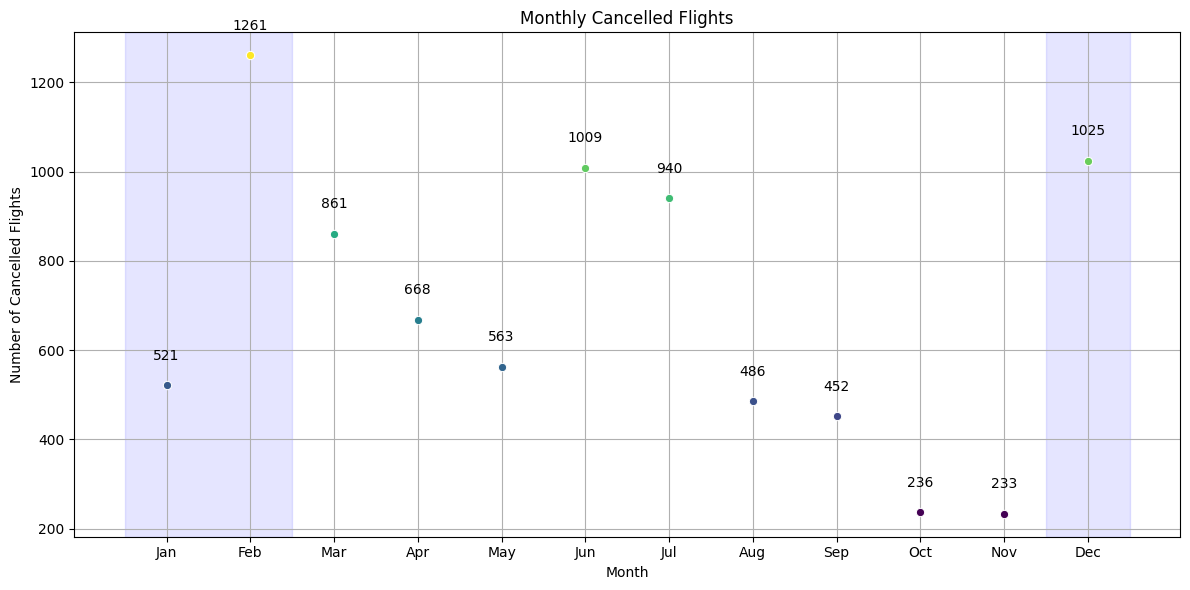

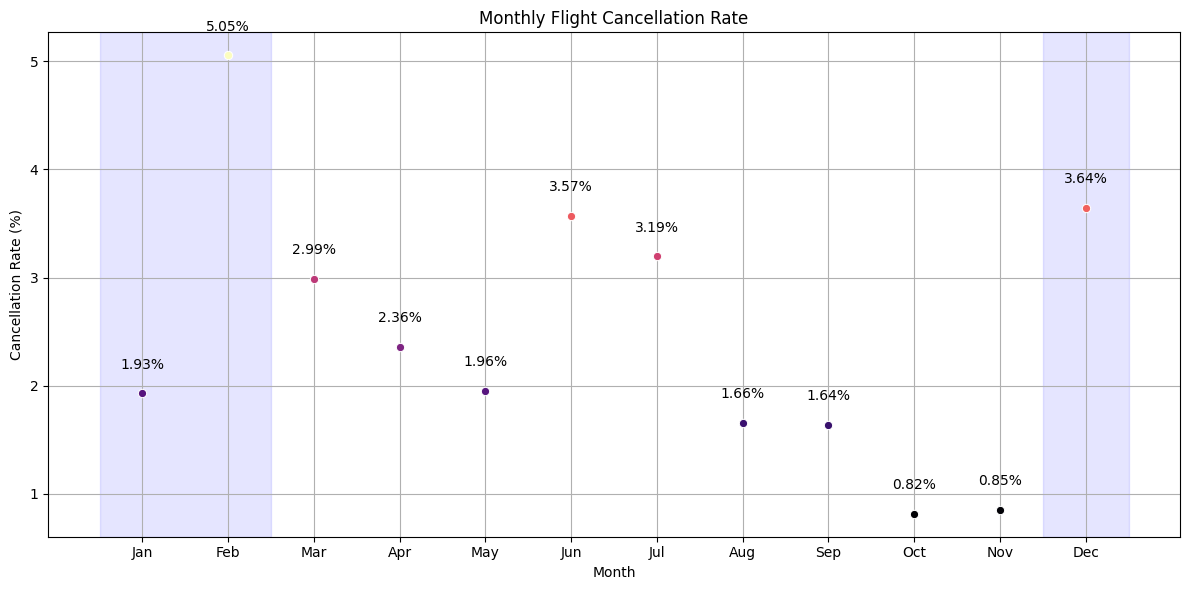

In [ ]:
plt.figure(figsize=(12, 6))
ax1 = sns.lineplot(x='month', y='cancelled_flights', data=monthly_cancellations, marker='o', hue='cancelled_flights', legend=False, palette='viridis')
plt.title('Monthly Cancelled Flights')
plt.xlabel('Month')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
for index, row in monthly_cancellations.iterrows():
    ax1.text(row['month'], row['cancelled_flights'] + 50, f'{row['cancelled_flights']:.0f}', color='black', ha='center', va='bottom')

# Highlight winter months (Dec, Jan, Feb)
ax1.axvspan(11.5, 12.5, color='blue', alpha=0.1, label='Winter Month') # December
ax1.axvspan(0.5, 2.5, color='blue', alpha=0.1) # January and February

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
ax2 = sns.lineplot(x='month', y='cancellation_rate', data=monthly_cancellations, marker='o', hue='cancellation_rate', legend=False, palette='magma')
plt.title('Monthly Flight Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
for index, row in monthly_cancellations.iterrows():
    ax2.text(row['month'], row['cancellation_rate'] + 0.2, f'{row['cancellation_rate']:.2f}%', color='black', ha='center', va='bottom')

# Highlight winter months (Dec, Jan, Feb)
ax2.axvspan(11.5, 12.5, color='blue', alpha=0.1, label='Winter Month') # December
ax2.axvspan(0.5, 2.5, color='blue', alpha=0.1) # January and February

plt.tight_layout()
plt.show()